In [58]:
import numpy as np
import scipy.stats as stats
from scipy.stats import norm



file1 = 'model.layers.0.self_attn_k_proj_50_histogram_data.npz'
file2 = 'model.layers.0.self_attn_k_proj_50_quantized_histogram_data.npz'
file3 = 'DGMS.npz'
# Load data from three npz files

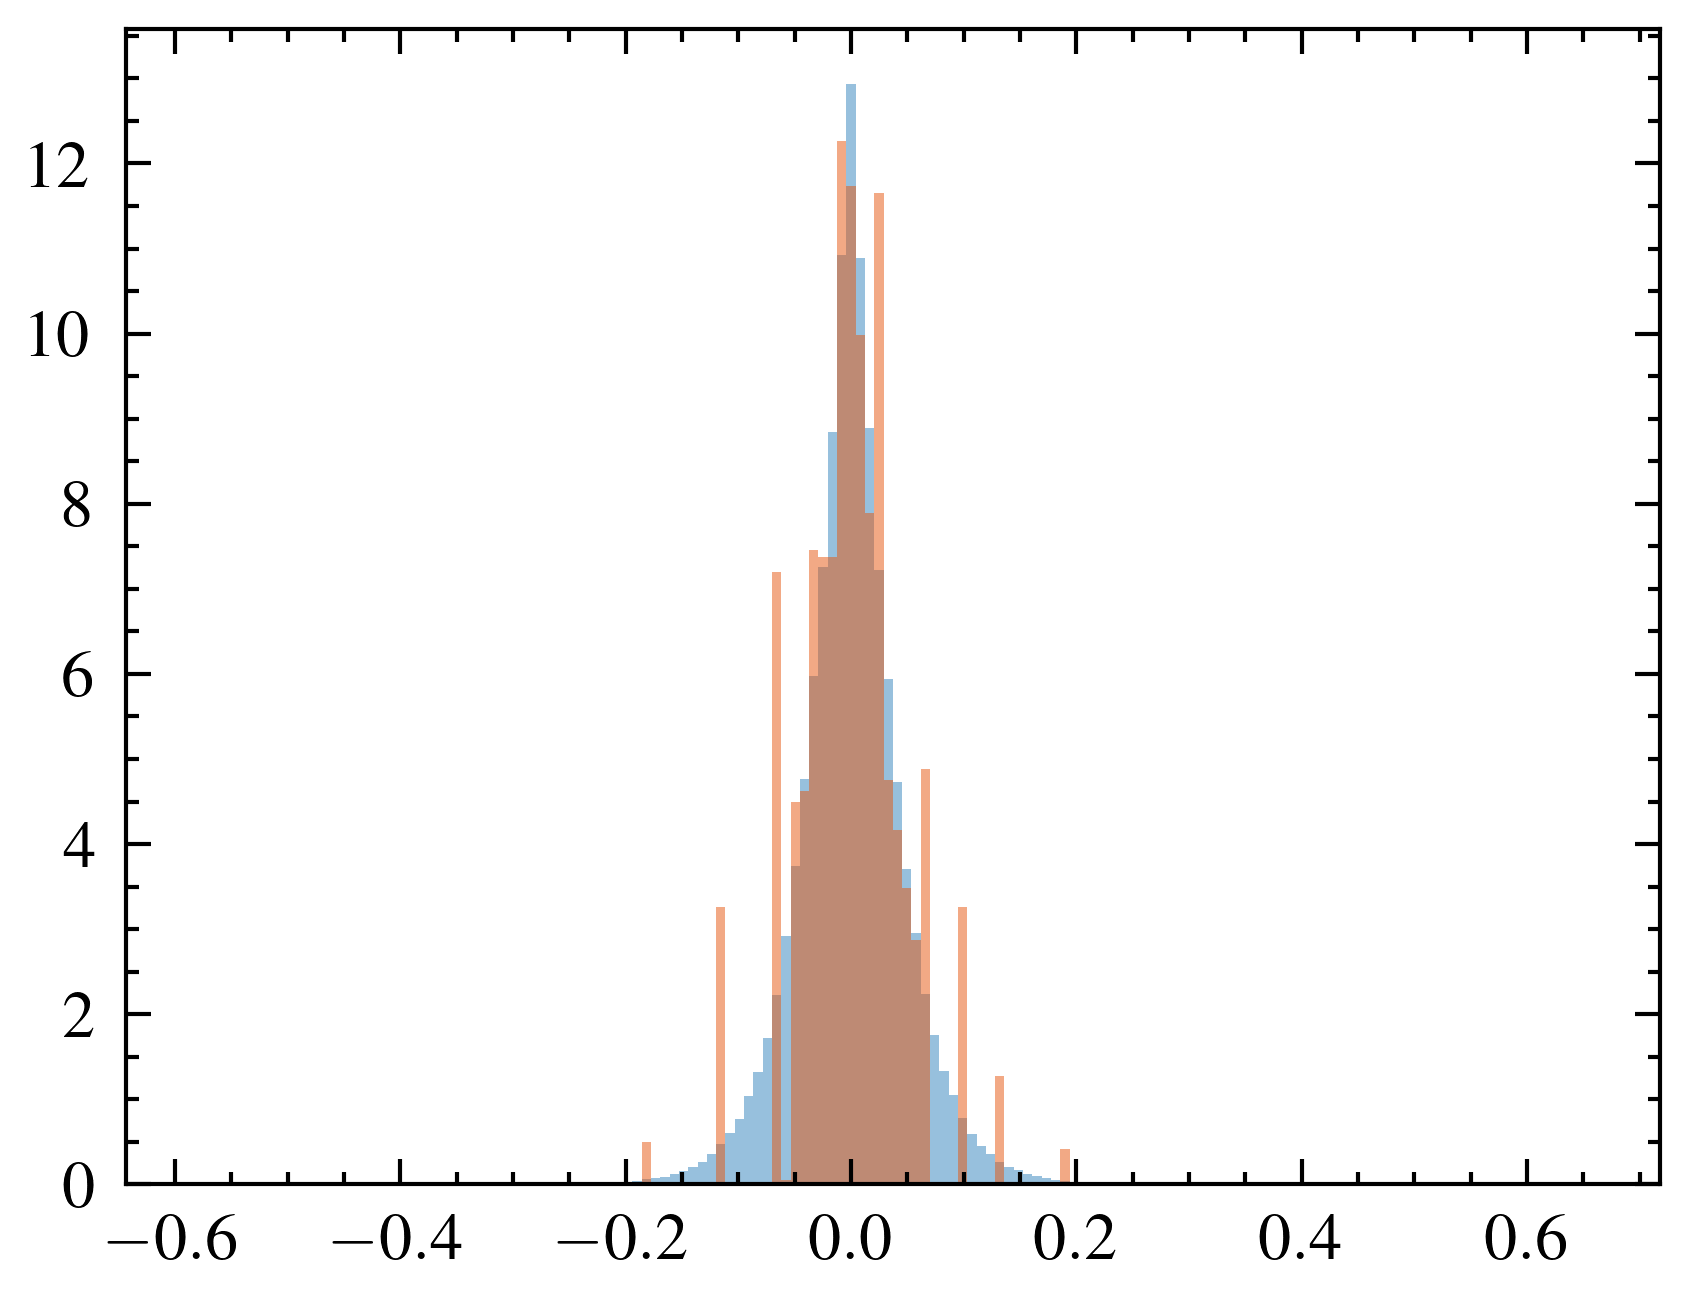

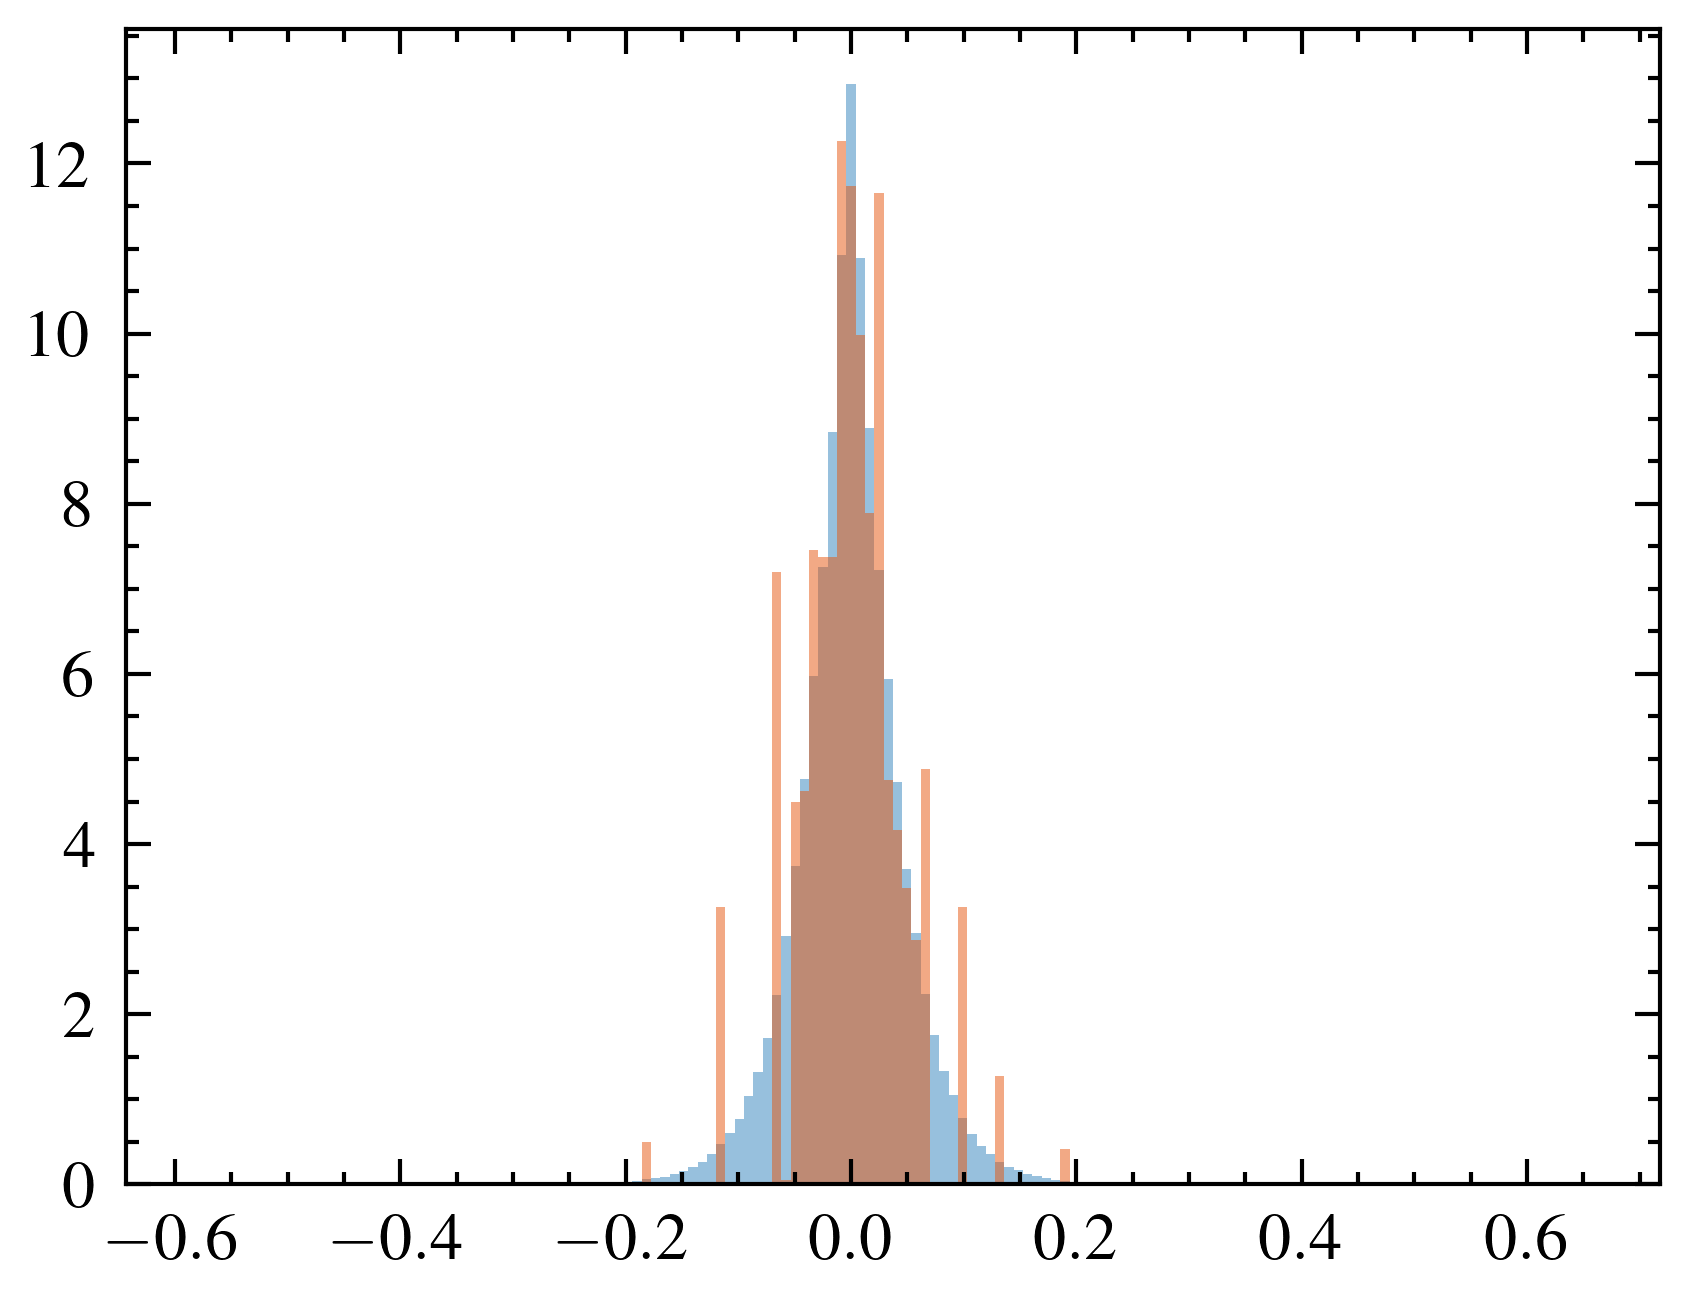

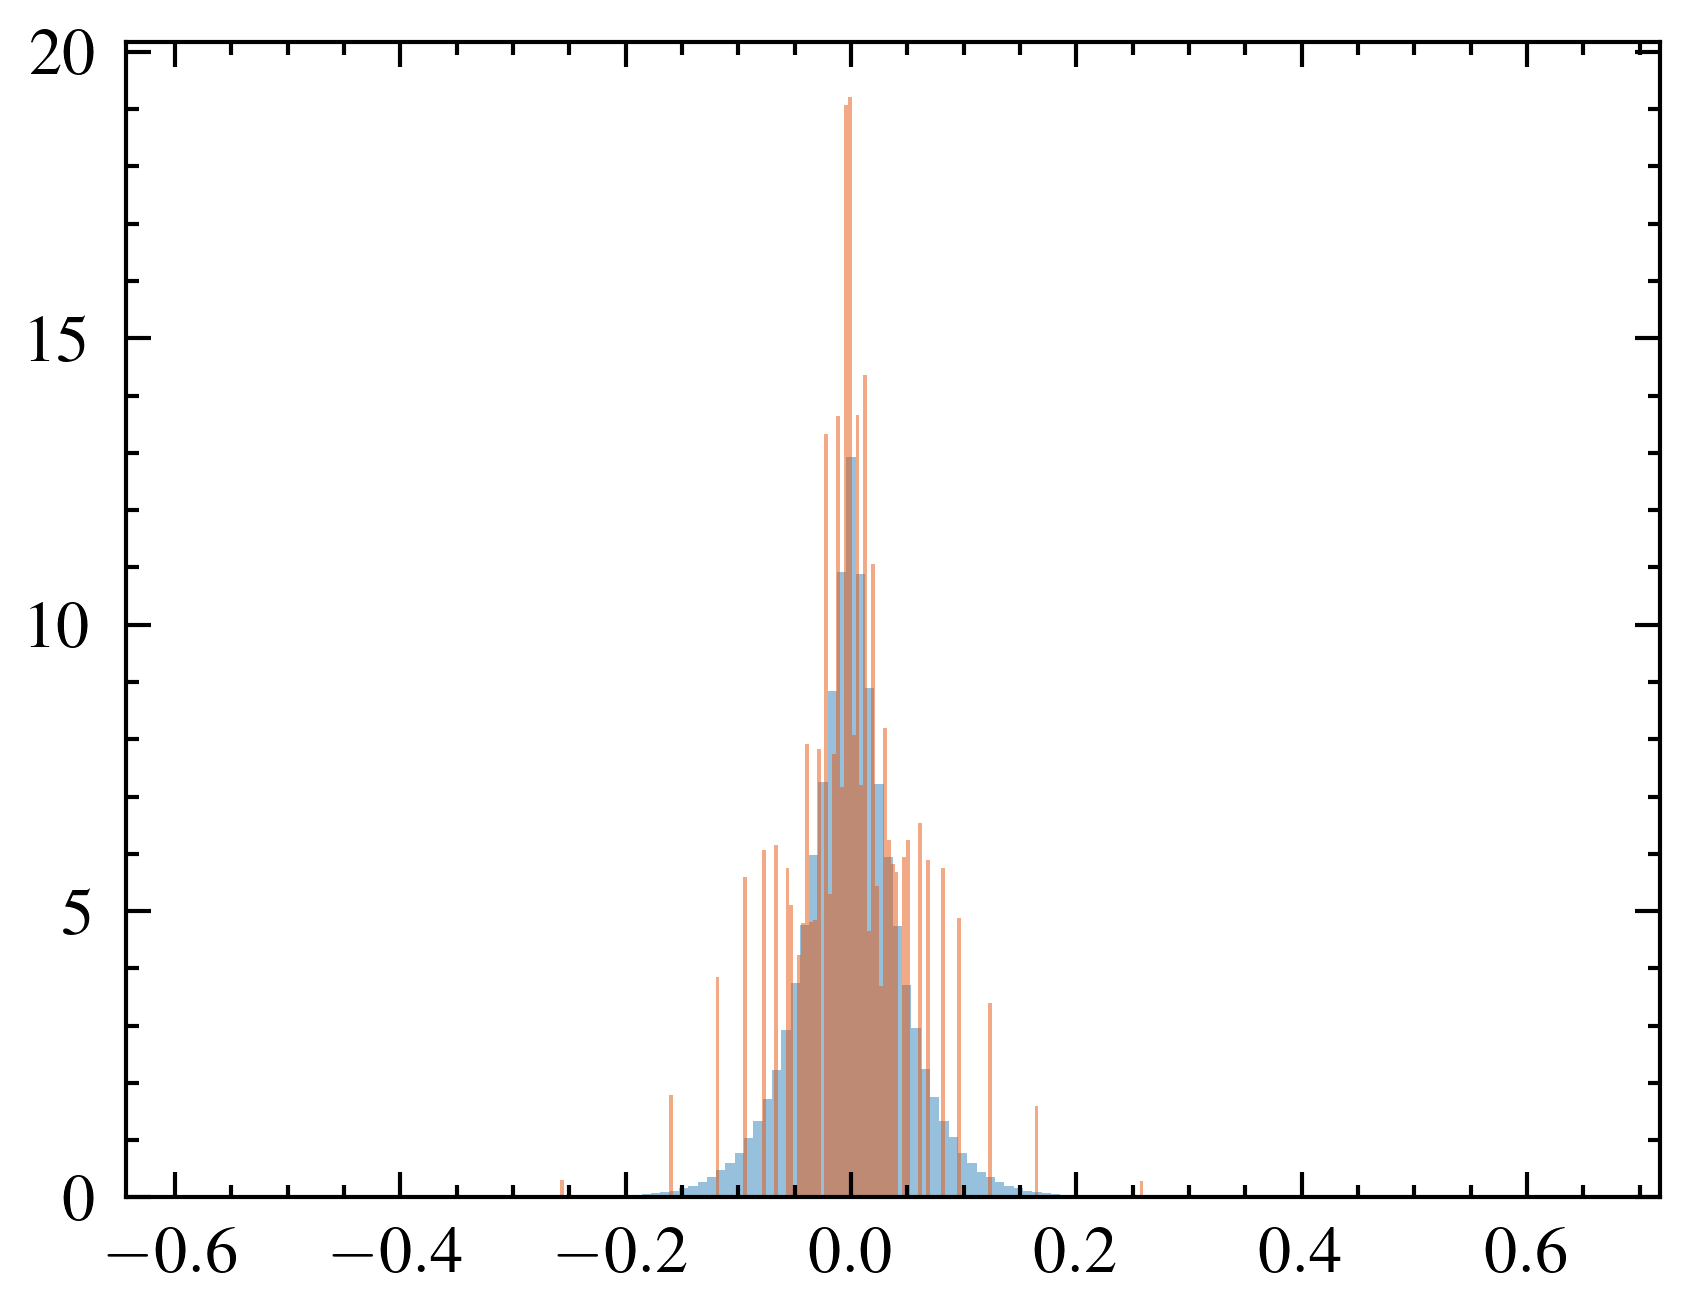

In [59]:
original_hist = np.load(file1,allow_pickle=True)
SQS_hist = np.load(file2,allow_pickle=True)
DGMS_hist = np.load(file3,allow_pickle=True)

original_counts = original_hist['counts']
original_bins = original_hist['bins']
original_bars = original_hist['bars']
mean = original_hist['mean']
std = original_hist['std']
q1 = original_hist['q1']
q3 = original_hist['q3']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

SQS_counts = SQS_hist['counts']
SQS_bins = SQS_hist['bins']
SQS_bars = SQS_hist['bars']

DGMS_counts = DGMS_hist['counts']
DGMS_bins = DGMS_hist['bins']
DGMS_bars = DGMS_hist['bars']

In [60]:

import matplotlib.pyplot as plt
import scienceplots
# Activate the 'science' style with 'std-colors'
plt.style.use(['science', 'std-colors'])

# Get the color cycle from current style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Now you can access individual colors
color1 = colors[0]
color2 = colors[1]
color0 = colors[-1]

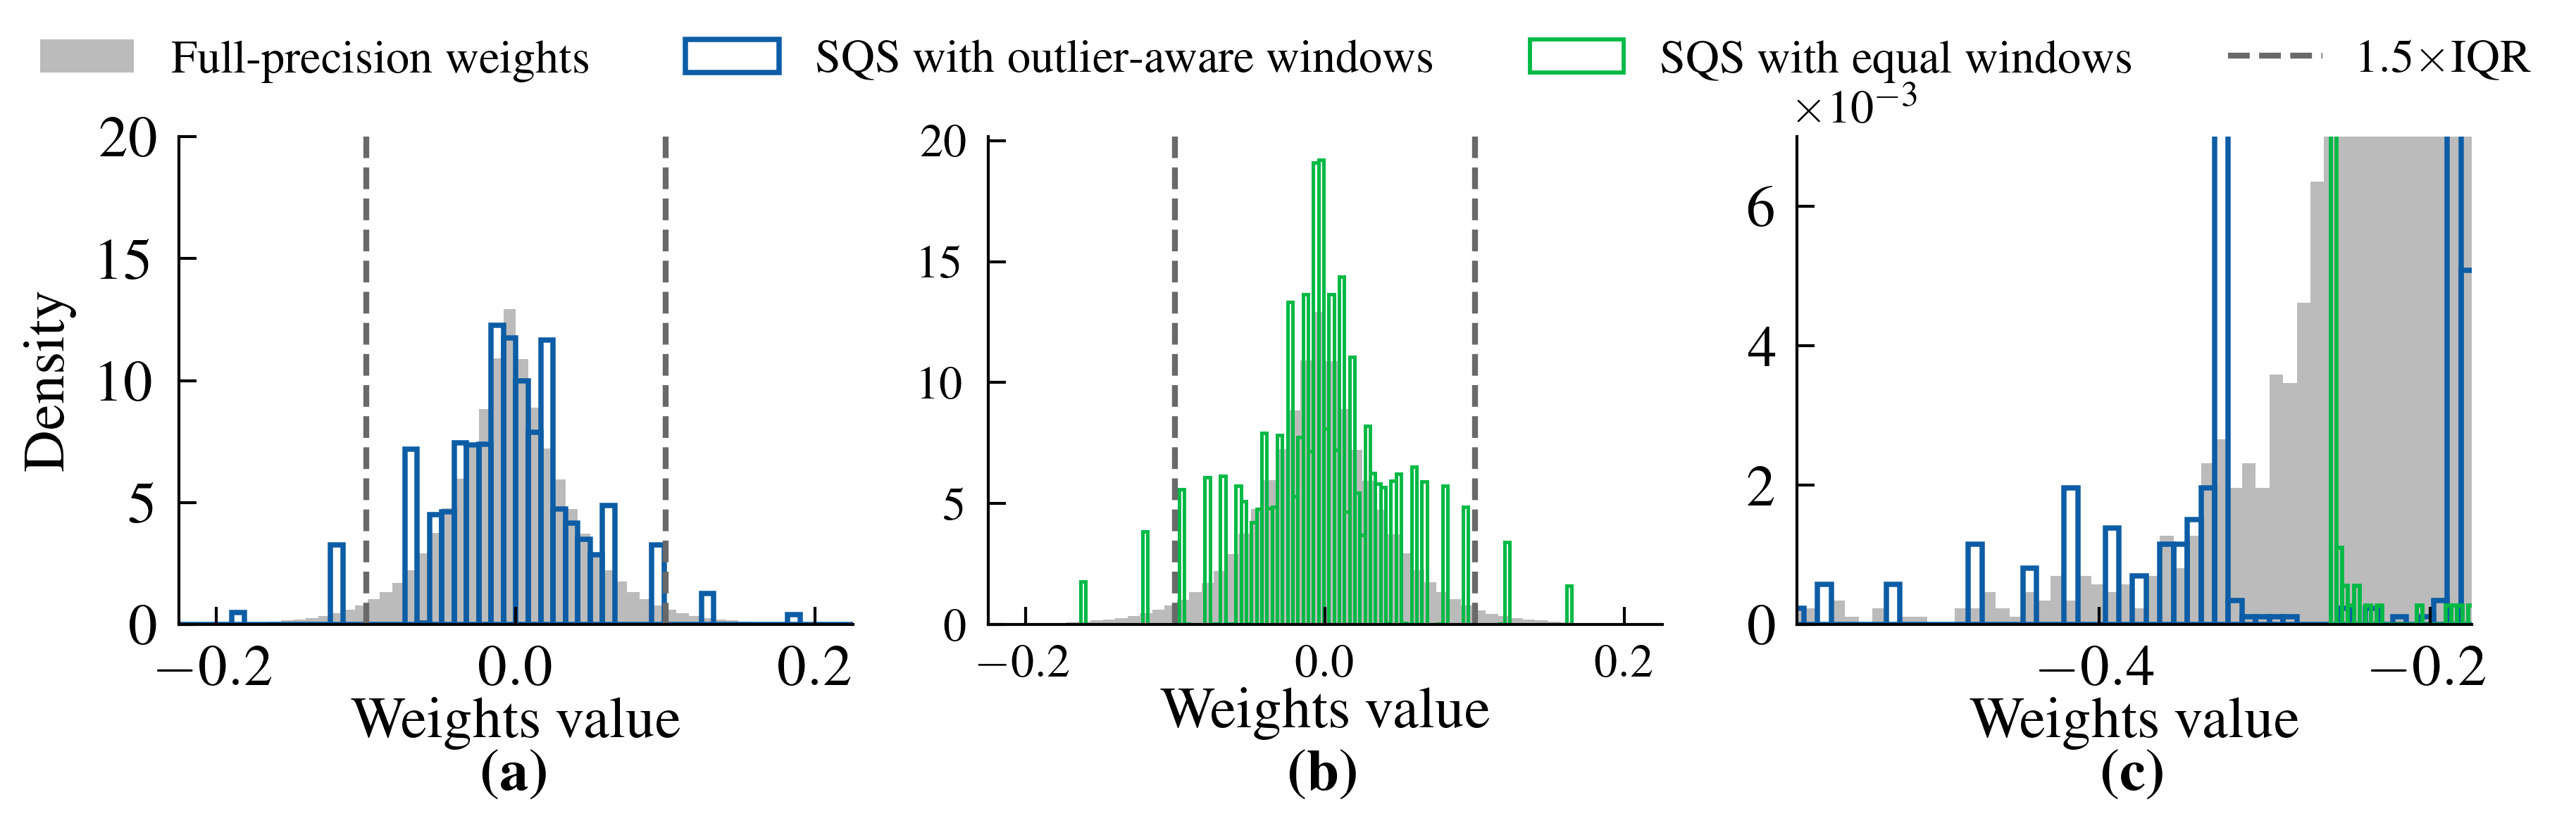

In [130]:

# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(7, 1.5))

axs[0].bar(original_bins[:-1], original_counts, width=np.diff(original_bins), alpha=0.7, facecolor=color0, label='Full-precision\nWeights')
axs[0].bar(SQS_bins[:-1], SQS_counts, width=np.diff(SQS_bins), alpha=1, edgecolor=color1, facecolor='none', linewidth=0.9,
           label='SQS')
axs[0].axvline(lower_bound, color='#696969', linestyle='--', label=r'$1.5\times$IQR')
axs[0].axvline(upper_bound, color='#696969', linestyle='--')

x = np.linspace(min(original_bins), max(original_bins), 1000)


axs[0].set_xlim(q1-4*iqr, q3+4*iqr)

axs[0].set_ylim(0, 20)

axs[1].bar(original_bins[:-1], original_counts, width=np.diff(original_bins), alpha=0.7, 
           facecolor=color0, label='Full-precision\nWeights')

axs[1].bar(DGMS_bins[:-1], DGMS_counts, width=np.diff(DGMS_bins), alpha=1,linewidth=0.6,
           edgecolor=color2, 
           facecolor='none', label='SQS\nEven Division')
axs[1].axvline(lower_bound, color='#696969', linestyle='--', label=r'$1.5\times$IQR')
axs[1].axvline(upper_bound, color='#696969', linestyle='--')
axs[1].set_xlim(q1-4*iqr, q3+4*iqr)

x = np.linspace(min(original_bins), max(original_bins), 1000)


axs[1].set_xlim(q1-4*iqr, q3+4*iqr)
axs[0].set_xlim(q1-4*iqr, q3+4*iqr)


axs[2].bar(original_bins[:-1], original_counts, width=np.diff(original_bins), alpha=0.7, color=color0, label='Full-precision weights')
axs[2].bar(SQS_bins[:-1], SQS_counts, width=np.diff(SQS_bins), alpha=1,  linewidth=0.9,
            edgecolor=color1, facecolor='none', label='SQS with outlier-aware windows')
axs[2].bar(DGMS_bins[:-1], DGMS_counts, width=np.diff(DGMS_bins), alpha=1, edgecolor=color2, linewidth=0.7,
           facecolor='none', label='SQS with equal windows')
axs[2].set_xlim(min(original_bins), q1-3*iqr)
axs[2].set_ylim(0, 7e-3)


# Set titles and labels

axs[0].set_ylabel('Density', fontsize=10)

axs[0].tick_params(axis='both', labelsize=10)
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=False)
formatter.set_powerlimits((0, 0))  # Force scientific notation
formatter.set_scientific(True)
axs[2].yaxis.set_major_formatter(formatter)
axs[2].tick_params(axis='both', labelsize=10)
pos = axs[2].get_position()
####
for i in range(3):
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['top'].set_visible(False)
    axs[i].tick_params(top=False, right=False)
    axs[i].tick_params(which='minor', length=0, color='white')
    axs[i].set_xlabel('Weights value', fontsize=10, labelpad=0)
####


axs[0].text(0.5, -0.31, r"\textbf{(a)}", transform=axs[0].transAxes,
            ha='center', va='center', fontsize=10)
axs[1].text(0.5, -0.31, r"\textbf{(b)}", transform=axs[1].transAxes,
            ha='center', va='center', fontsize=10)
axs[2].text(0.5, -0.31, r"\textbf{(c)}", transform=axs[2].transAxes,
            ha='center', va='center', fontsize=10)
# Share legend between subplots
handles, legend_labels = axs[2].get_legend_handles_labels()
handles2, legend_labels2 = axs[0].get_legend_handles_labels()
handles.append(handles2[0])
legend_labels.append(legend_labels2[0])


fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.1),
           ncol=len(handles), fontsize=8, frameon=False)

plt.savefig('weight_distribution.pdf',format='pdf', bbox_inches='tight',  pad_inches=0)
plt.show()